In [2]:
# Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os

# Project paths
BASE_DIR  = r"C:\Users\Hunter\OneDrive - Grand Canyon University\Documents\GitHub Projects\gcu-capstone-project"
DATA_DIR  = os.path.join(BASE_DIR, "data")
OUT_DIR   = os.path.join(BASE_DIR, "outputs")

# Plot style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor": "#FAFAFA"
})

TARGET_RED  = "#CC0000"
TARGET_GRAY = "#666666"

print("✅ Imports OK")
print(f"Data folder exists: {os.path.exists(DATA_DIR)}")
print(f"Outputs folder exists: {os.path.exists(OUT_DIR)}")

✅ Imports OK
Data folder exists: True
Outputs folder exists: True


In [3]:
# Load Raw Data
orders    = pd.read_csv(os.path.join(DATA_DIR, "olist_orders_dataset.csv"),
                        parse_dates=["order_purchase_timestamp"])
customers = pd.read_csv(os.path.join(DATA_DIR, "olist_customers_dataset.csv"))
payments  = pd.read_csv(os.path.join(DATA_DIR, "olist_order_payments_dataset.csv"))
items     = pd.read_csv(os.path.join(DATA_DIR, "olist_order_items_dataset.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "olist_products_dataset.csv"))
sellers   = pd.read_csv(os.path.join(DATA_DIR, "olist_sellers_dataset.csv"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "olist_order_reviews_dataset.csv"))
geo       = pd.read_csv(os.path.join(DATA_DIR, "olist_geolocation_dataset.csv"))
cat_trans = pd.read_csv(os.path.join(DATA_DIR, "product_category_name_translation.csv"))

print(f"orders:    {orders.shape}")
print(f"customers: {customers.shape}")
print(f"payments:  {payments.shape}")
print(f"items:     {items.shape}")
print(f"products:  {products.shape}")
print(f"sellers:   {sellers.shape}")
print(f"reviews:   {reviews.shape}")
print(f"geo:       {geo.shape}")
print(f"cat_trans: {cat_trans.shape}")
print("\n✅ All tables loaded")

orders:    (99441, 8)
customers: (99441, 5)
payments:  (103886, 5)
items:     (112650, 7)
products:  (32951, 9)
sellers:   (3095, 4)
reviews:   (99224, 7)
geo:       (1000163, 5)
cat_trans: (71, 2)

✅ All tables loaded


In [4]:
# Filter and Merge
# Keep only delivered orders
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# Total payment per order (some orders have multiple payment rows)
order_value = payments.groupby("order_id")["payment_value"].sum().reset_index()
order_value.columns = ["order_id", "order_total"]

# Merge orders + customers + payment totals
df = orders_delivered.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]],
    on="customer_id"
)
df = df.merge(order_value, on="order_id")

print(f"Delivered orders:  {len(df):,}")
print(f"Unique customers:  {df['customer_unique_id'].nunique():,}")
print(f"Date range:        {df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}")
print(f"Null check:\n{df[['order_purchase_timestamp','order_total','customer_unique_id']].isnull().sum()}")
print("\n✅ Merge complete")

Delivered orders:  96,477
Unique customers:  93,357
Date range:        2016-10-03 to 2018-08-29
Null check:
order_purchase_timestamp    0
order_total                 0
customer_unique_id          0
dtype: int64

✅ Merge complete


In [5]:
# Build RFM Table
# Snapshot date = one day after the most recent order
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_unique_id").agg(
    Recency  =("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "count"),
    Monetary =("order_total", "sum")
).reset_index()

print(f"Snapshot date: {snapshot_date.date()}")
print(f"RFM table shape: {rfm.shape}")
print(f"\nRFM Summary:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))
print(f"\nFrequency distribution (top 5):")
print(rfm["Frequency"].value_counts().head())
print(f"\n% single-purchase customers: {(rfm['Frequency'] == 1).mean() * 100:.1f}%")
print("\n✅ RFM table built")

Snapshot date: 2018-08-30
RFM table shape: (93357, 4)

RFM Summary:
        Recency  Frequency  Monetary
count  93357.00   93357.00  93357.00
mean     237.94       1.03    165.20
std      152.58       0.21    226.31
min        1.00       1.00      9.59
25%      114.00       1.00     63.06
50%      219.00       1.00    107.78
75%      346.00       1.00    182.56
max      695.00      15.00  13664.08

Frequency distribution (top 5):
Frequency
1    90556
2     2573
3      181
4       28
5        9
Name: count, dtype: int64

% single-purchase customers: 97.0%

✅ RFM table built


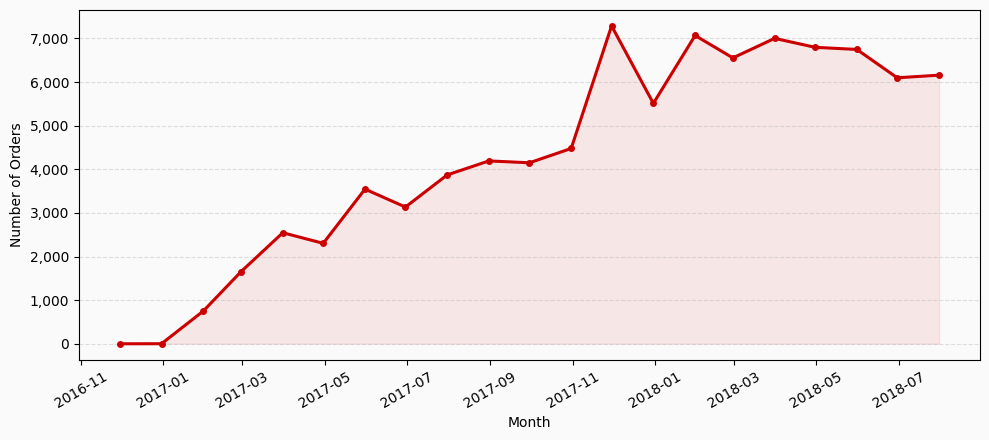

✅ Figure 1 saved to outputs/


In [6]:
# Figure 1: Monthly Order Volume Trend (Line Chart)
monthly = (df.set_index("order_purchase_timestamp")
             .resample("ME")["order_id"]
             .count()
             .reset_index())
monthly.columns = ["Month", "Order_Count"]
monthly = monthly.iloc[1:-1]  # drop partial edge months

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly["Month"], monthly["Order_Count"],
        color=TARGET_RED, linewidth=2.2, marker="o", markersize=4)
ax.fill_between(monthly["Month"], monthly["Order_Count"],
                alpha=0.08, color=TARGET_RED)
ax.set_xlabel("Month", fontsize=10)
ax.set_ylabel("Number of Orders", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig1_line_monthly_orders.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 saved to outputs/")

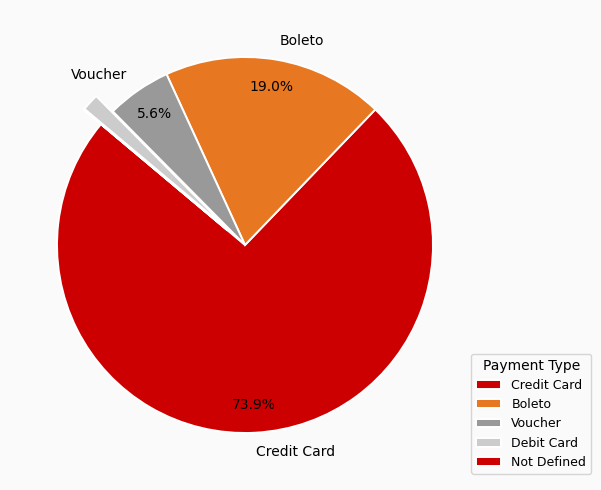

✅ Figure 2 saved to outputs/


In [7]:
# Figure 2: Payment Type Distribution (Pie Chart)
pay_counts = payments["payment_type"].value_counts()
labels_clean = [t.replace("_", " ").title() for t in pay_counts.index]

# Suppress labels for slices under 3%, let legend handle them
threshold = 0.03
total = pay_counts.sum()
pie_labels = [name if (pay_counts.iloc[i] / total) >= threshold else ""
              for i, name in enumerate(labels_clean)]

# Explode small slices outward
explode = [0 if (pay_counts.iloc[i] / total) >= threshold else 0.12
           for i in range(len(pay_counts))]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    pay_counts,
    labels=pie_labels,
    autopct="%1.1f%%",
    colors=[TARGET_RED, "#E87722", "#999999", "#CCCCCC"],
    startangle=140,
    pctdistance=0.85,
    explode=explode,
    wedgeprops={"edgecolor": "white", "linewidth": 1.4}
)

# Hide pct labels on tiny slices to reduce noise
for i, autotext in enumerate(autotexts):
    if (pay_counts.iloc[i] / total) < threshold:
        autotext.set_visible(False)

# Legend for all slices
ax.legend(wedges, labels_clean,
          title="Payment Type",
          loc="lower right",
          bbox_to_anchor=(1.25, 0.0),
          fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig2_pie_payment_type.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2 saved to outputs/")

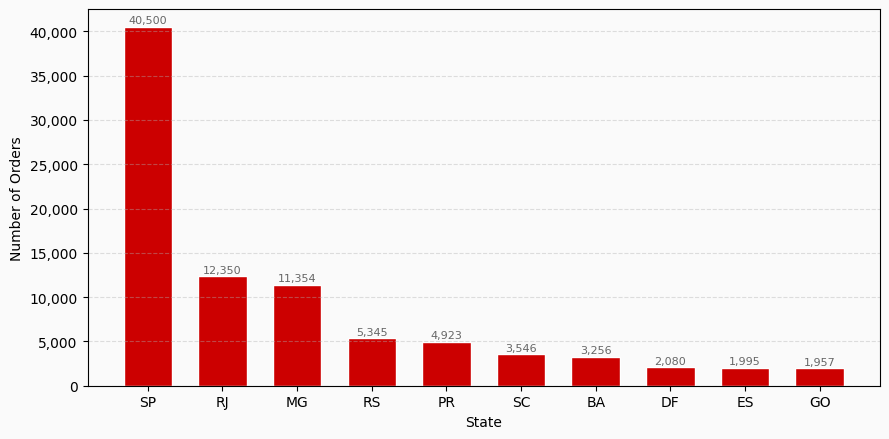

✅ Figure 3 saved to outputs/


In [8]:
# Figure 3: Top 10 Customer States by Order Volume (Bar Chart)
state_counts = df["customer_state"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(state_counts.index, state_counts.values,
              color=TARGET_RED, edgecolor="white", width=0.65)
ax.set_xlabel("State", fontsize=10)
ax.set_ylabel("Number of Orders", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}",
            ha="center", va="bottom", fontsize=8, color=TARGET_GRAY)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig3_bar_top_states.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3 saved to outputs/")

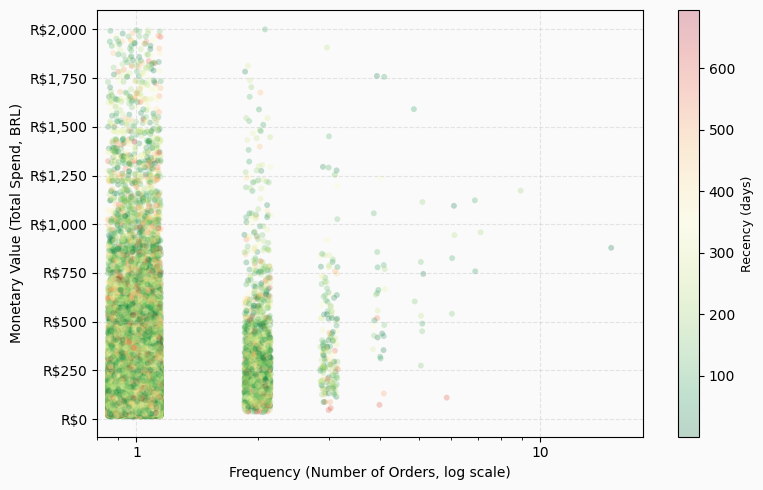

✅ Figure 4 saved to outputs/


In [9]:
# Figure 4: Frequency vs. Monetary Value (Scatter Plot)
rfm_plot = rfm[rfm["Monetary"] <= 2000].copy()

# Jitter frequency to break up the vertical stacking
np.random.seed(42)
jitter = np.random.uniform(-0.15, 0.15, size=len(rfm_plot))

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(rfm_plot["Frequency"] + jitter, rfm_plot["Monetary"],
                alpha=0.25, s=18,
                c=rfm_plot["Recency"], cmap="RdYlGn_r",
                edgecolors="none")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Recency (days)", fontsize=9)

# Log scale on x to spread out the heavy left skew
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_xlim(0.8, rfm_plot["Frequency"].max() * 1.2)

ax.set_xlabel("Frequency (Number of Orders, log scale)", fontsize=10)
ax.set_ylabel("Monetary Value (Total Spend, BRL)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig4_scatter_freq_monetary.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 saved to outputs/")

In [10]:
# Hypothesis Test
# H0: Mean monetary value is equal for single-purchase vs. repeat customers
# H1: Mean monetary value is significantly higher for repeat customers

single = rfm[rfm["Frequency"] == 1]["Monetary"]
repeat = rfm[rfm["Frequency"] >= 2]["Monetary"]

t_stat, p_val = stats.ttest_ind(repeat, single, equal_var=False)

print("=== HYPOTHESIS TEST ===")
print("H0: Single-purchase and repeat customers spend the same amount on average")
print("H1: Repeat customers spend significantly more than single-purchase customers")
print()
print(f"Single-purchase customers  n={len(single):,}   mean=R${single.mean():.2f}   std=R${single.std():.2f}")
print(f"Repeat customers           n={len(repeat):,}    mean=R${repeat.mean():.2f}  std=R${repeat.std():.2f}")
print()
print(f"Welch's t-statistic: {t_stat:.4f}")
print(f"p-value:             {p_val:.8f}")
print()
if p_val < 0.05:
    print("✅ REJECT H0 — Repeat customers spend significantly more (p < 0.05)")
else:
    print("❌ FAIL TO REJECT H0")

=== HYPOTHESIS TEST ===
H0: Single-purchase and repeat customers spend the same amount on average
H1: Repeat customers spend significantly more than single-purchase customers

Single-purchase customers  n=90,556   mean=R$160.76   std=R$221.45
Repeat customers           n=2,801    mean=R$308.59  std=R$316.98

Welch's t-statistic: 24.4974
p-value:             0.00000000

✅ REJECT H0 — Repeat customers spend significantly more (p < 0.05)


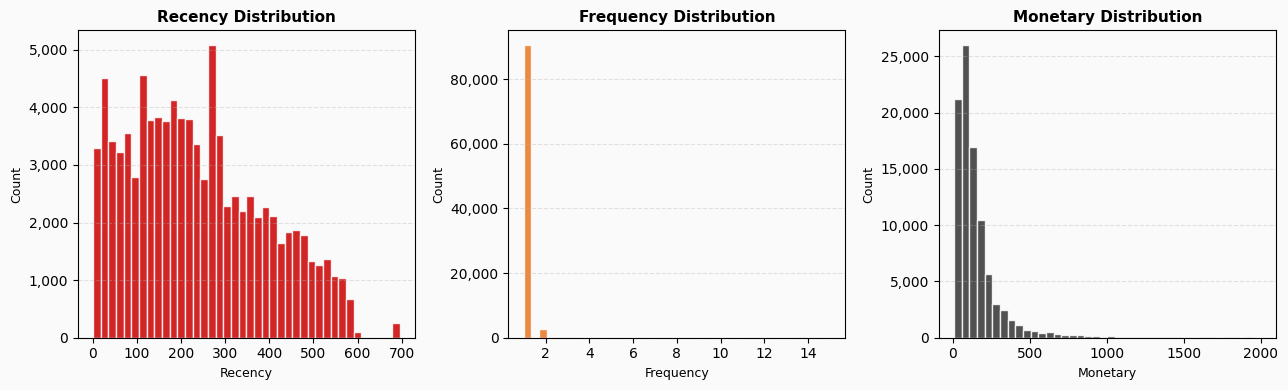

✅ Figure 5 saved to outputs/


In [11]:
# Figure 5: RFM Distributions (Data Quality Check)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

configs = [
    ("Recency",   rfm["Recency"],                          TARGET_RED),
    ("Frequency", rfm["Frequency"],                        "#E87722"),
    ("Monetary",  rfm[rfm["Monetary"] <= 2000]["Monetary"],"#333333"),
]

for ax, (col, data, color) in zip(axes, configs):
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{col} Distribution", fontsize=11, fontweight="bold")
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig5_rfm_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 5 saved to outputs/")

In [12]:
# Export RFM Table
rfm_export = rfm.copy()
rfm_export.columns = [
    "Customer Unique ID",
    "Recency (Days Since Last Purchase)",
    "Frequency (Number of Orders)",
    "Monetary (Total Spend BRL)"
]

export_path = os.path.join(OUT_DIR, "rfm_table.csv")
rfm_export.to_csv(export_path, index=False)

print(f"✅ RFM table exported: {len(rfm_export):,} rows")
print(f"   Saved to: {export_path}")
print(f"\nPreview:")
print(rfm_export.head(10).to_string(index=False))

✅ RFM table exported: 93,357 rows
   Saved to: C:\Users\Hunter\OneDrive - Grand Canyon University\Documents\GitHub Projects\gcu-capstone-project\outputs\rfm_table.csv

Preview:
              Customer Unique ID  Recency (Days Since Last Purchase)  Frequency (Number of Orders)  Monetary (Total Spend BRL)
0000366f3b9a7992bf8c76cfdf3221e2                                 112                             1                      141.90
0000b849f77a49e4a4ce2b2a4ca5be3f                                 115                             1                       27.19
0000f46a3911fa3c0805444483337064                                 537                             1                       86.22
0000f6ccb0745a6a4b88665a16c9f078                                 321                             1                       43.62
0004aac84e0df4da2b147fca70cf8255                                 288                             1                      196.89
0004bd2a26a76fe21f786e4fbd80607f                             

In [13]:
# Build Excel Raw Data File
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = Workbook()

# ── Sheet 1: RFM Table ────────────────────────────────────────────────────────
ws1 = wb.active
ws1.title = "RFM Table"

headers = [
    "Guest Unique ID",
    "Recency (Days Since Last Purchase)",
    "Frequency (Number of Orders)",
    "Monetary (Total Spend BRL)"
]

header_fill = PatternFill("solid", start_color="CC0000", end_color="CC0000")
header_font = Font(bold=True, color="FFFFFF", name="Arial", size=11)
center      = Alignment(horizontal="center", vertical="center")
thin        = Side(style="thin", color="CCCCCC")
border      = Border(left=thin, right=thin, top=thin, bottom=thin)

# Write headers
for col, h in enumerate(headers, 1):
    cell = ws1.cell(row=1, column=col, value=h)
    cell.font      = header_font
    cell.fill      = header_fill
    cell.alignment = center
    cell.border    = border

# Write data rows
for row_idx, row in enumerate(rfm_export.values, 2):
    for col_idx, value in enumerate(row, 1):
        cell = ws1.cell(row=row_idx, column=col_idx, value=value)
        cell.font      = Font(name="Arial", size=10)
        cell.alignment = center
        cell.border    = border

# Column widths
ws1.column_dimensions["A"].width = 42
ws1.column_dimensions["B"].width = 36
ws1.column_dimensions["C"].width = 30
ws1.column_dimensions["D"].width = 28
ws1.row_dimensions[1].height = 22

# ── Sheet 2: Summary Statistics ───────────────────────────────────────────────
ws2 = wb.create_sheet("Summary Statistics")

summary_headers = ["Metric", "Recency (Days)", "Frequency (Orders)", "Monetary (BRL)"]
summary_rows = [
    ("Count",    f"{rfm['Recency'].count():,}",  f"{rfm['Frequency'].count():,}",  f"{rfm['Monetary'].count():,}"),
    ("Mean",     f"{rfm['Recency'].mean():.1f}", f"{rfm['Frequency'].mean():.2f}", f"R${rfm['Monetary'].mean():.2f}"),
    ("Std Dev",  f"{rfm['Recency'].std():.1f}",  f"{rfm['Frequency'].std():.2f}",  f"R${rfm['Monetary'].std():.2f}"),
    ("Min",      f"{rfm['Recency'].min():.0f}",  f"{rfm['Frequency'].min():.0f}",  f"R${rfm['Monetary'].min():.2f}"),
    ("25th Pct", f"{rfm['Recency'].quantile(.25):.0f}", f"{rfm['Frequency'].quantile(.25):.0f}", f"R${rfm['Monetary'].quantile(.25):.2f}"),
    ("Median",   f"{rfm['Recency'].median():.0f}", f"{rfm['Frequency'].median():.0f}", f"R${rfm['Monetary'].median():.2f}"),
    ("75th Pct", f"{rfm['Recency'].quantile(.75):.0f}", f"{rfm['Frequency'].quantile(.75):.0f}", f"R${rfm['Monetary'].quantile(.75):.2f}"),
    ("Max",      f"{rfm['Recency'].max():.0f}",  f"{rfm['Frequency'].max():.0f}",  f"R${rfm['Monetary'].max():.2f}"),
]

for col, h in enumerate(summary_headers, 1):
    cell = ws2.cell(row=1, column=col, value=h)
    cell.font      = header_font
    cell.fill      = header_fill
    cell.alignment = center
    cell.border    = border

for row_idx, row in enumerate(summary_rows, 2):
    for col_idx, value in enumerate(row, 1):
        cell = ws2.cell(row=row_idx, column=col_idx, value=value)
        cell.font      = Font(name="Arial", size=10)
        cell.alignment = center
        cell.border    = border

for col in ["A","B","C","D"]:
    ws2.column_dimensions[col].width = 26
ws2.row_dimensions[1].height = 22

# ── Save ──────────────────────────────────────────────────────────────────────
excel_path = os.path.join(OUT_DIR, "topic2_raw_data.xlsx")
wb.save(excel_path)
print(f"✅ Excel file saved: {excel_path}")
print(f"   Sheet 1: RFM Table ({len(rfm_export):,} rows)")
print(f"   Sheet 2: Summary Statistics")

✅ Excel file saved: C:\Users\Hunter\OneDrive - Grand Canyon University\Documents\GitHub Projects\gcu-capstone-project\outputs\topic2_raw_data.xlsx
   Sheet 1: RFM Table (93,357 rows)
   Sheet 2: Summary Statistics
